In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import style
style.use('ggplot')
import warnings 
warnings.filterwarnings('ignore')


In [9]:
df = pd.read_csv("Desktop\machine learing\Position_Salaries.csv")
df

,Position,Level,Salary
0,Business Analyst,1,45000
1,Junior Consultant,2,50000
2,Senior Consultant,3,60000
3,Manager,4,80000
4,Country Manager,5,110000
5,Region Manager,6,150000
6,Partner,7,200000
7,Senior Partner,8,300000
8,C-level,9,500000
9,CEO,10,1000000


In [11]:
df.head()

,Position,Level,Salary
0,Business Analyst,1,45000
1,Junior Consultant,2,50000
2,Senior Consultant,3,60000
3,Manager,4,80000
4,Country Manager,5,110000


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Position  10 non-null     object
 1   Level     10 non-null     int64 
 2   Salary    10 non-null     int64 
dtypes: int64(2), object(1)
memory usage: 372.0+ bytes


In [15]:
df.duplicated().sum()

0

In [17]:
df.isnull().sum()

Position    0
Level       0
Salary      0
dtype: int64

<function matplotlib.pyplot.show(close=None, block=None)>

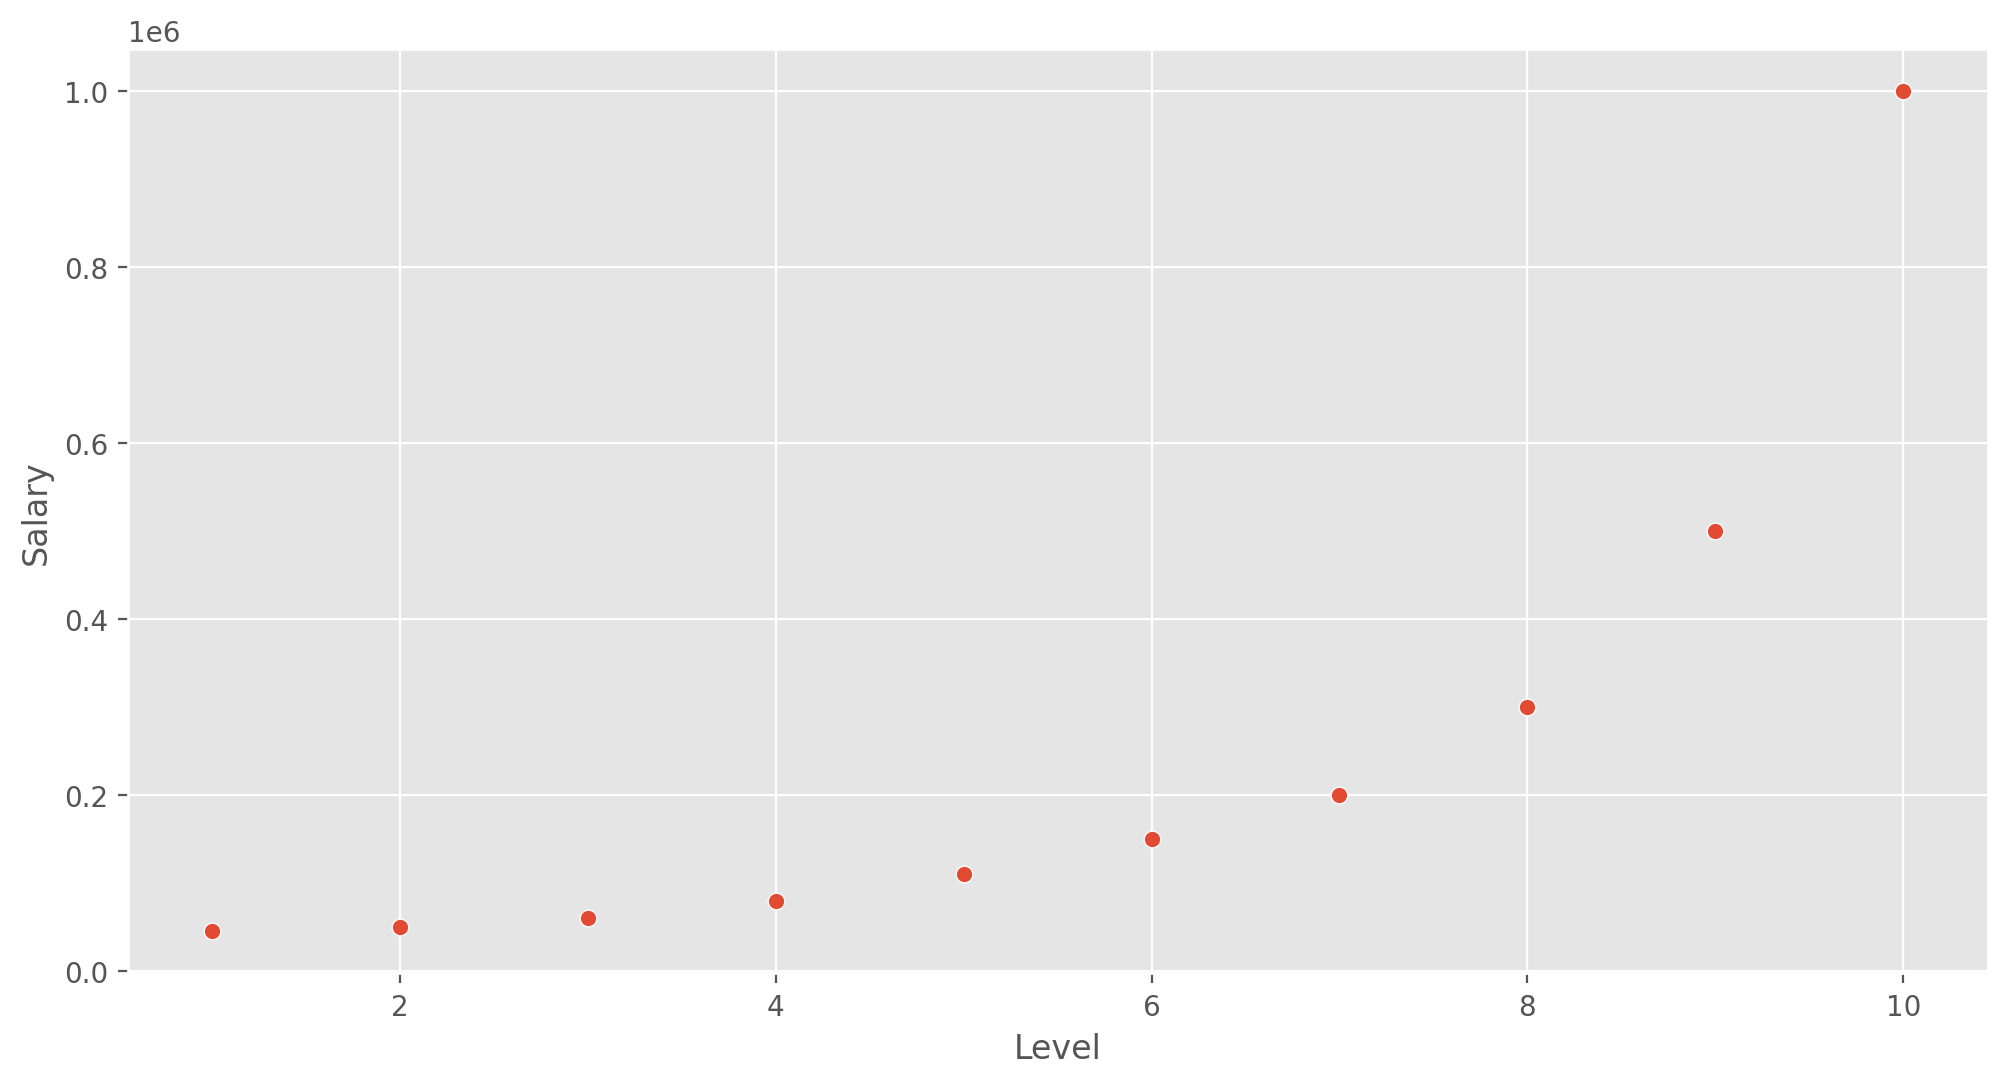

In [37]:
plt.figure(figsize =(12,6), dpi = 200) #dpi is the pixel
sns.scatterplot(x='Level', y='Salary', data = df)
plt.show

In [39]:
x = df[['Level']].values
y = df[['Salary']].values

In [41]:
#lets try to find simple linear regression 
#y' = B0 + B1X

In [43]:
from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression()
lin_reg.fit(x,y)

LinearRegression()

In [45]:
lin_reg.score(x,y) #to check the accuary 

0.6690412331929895

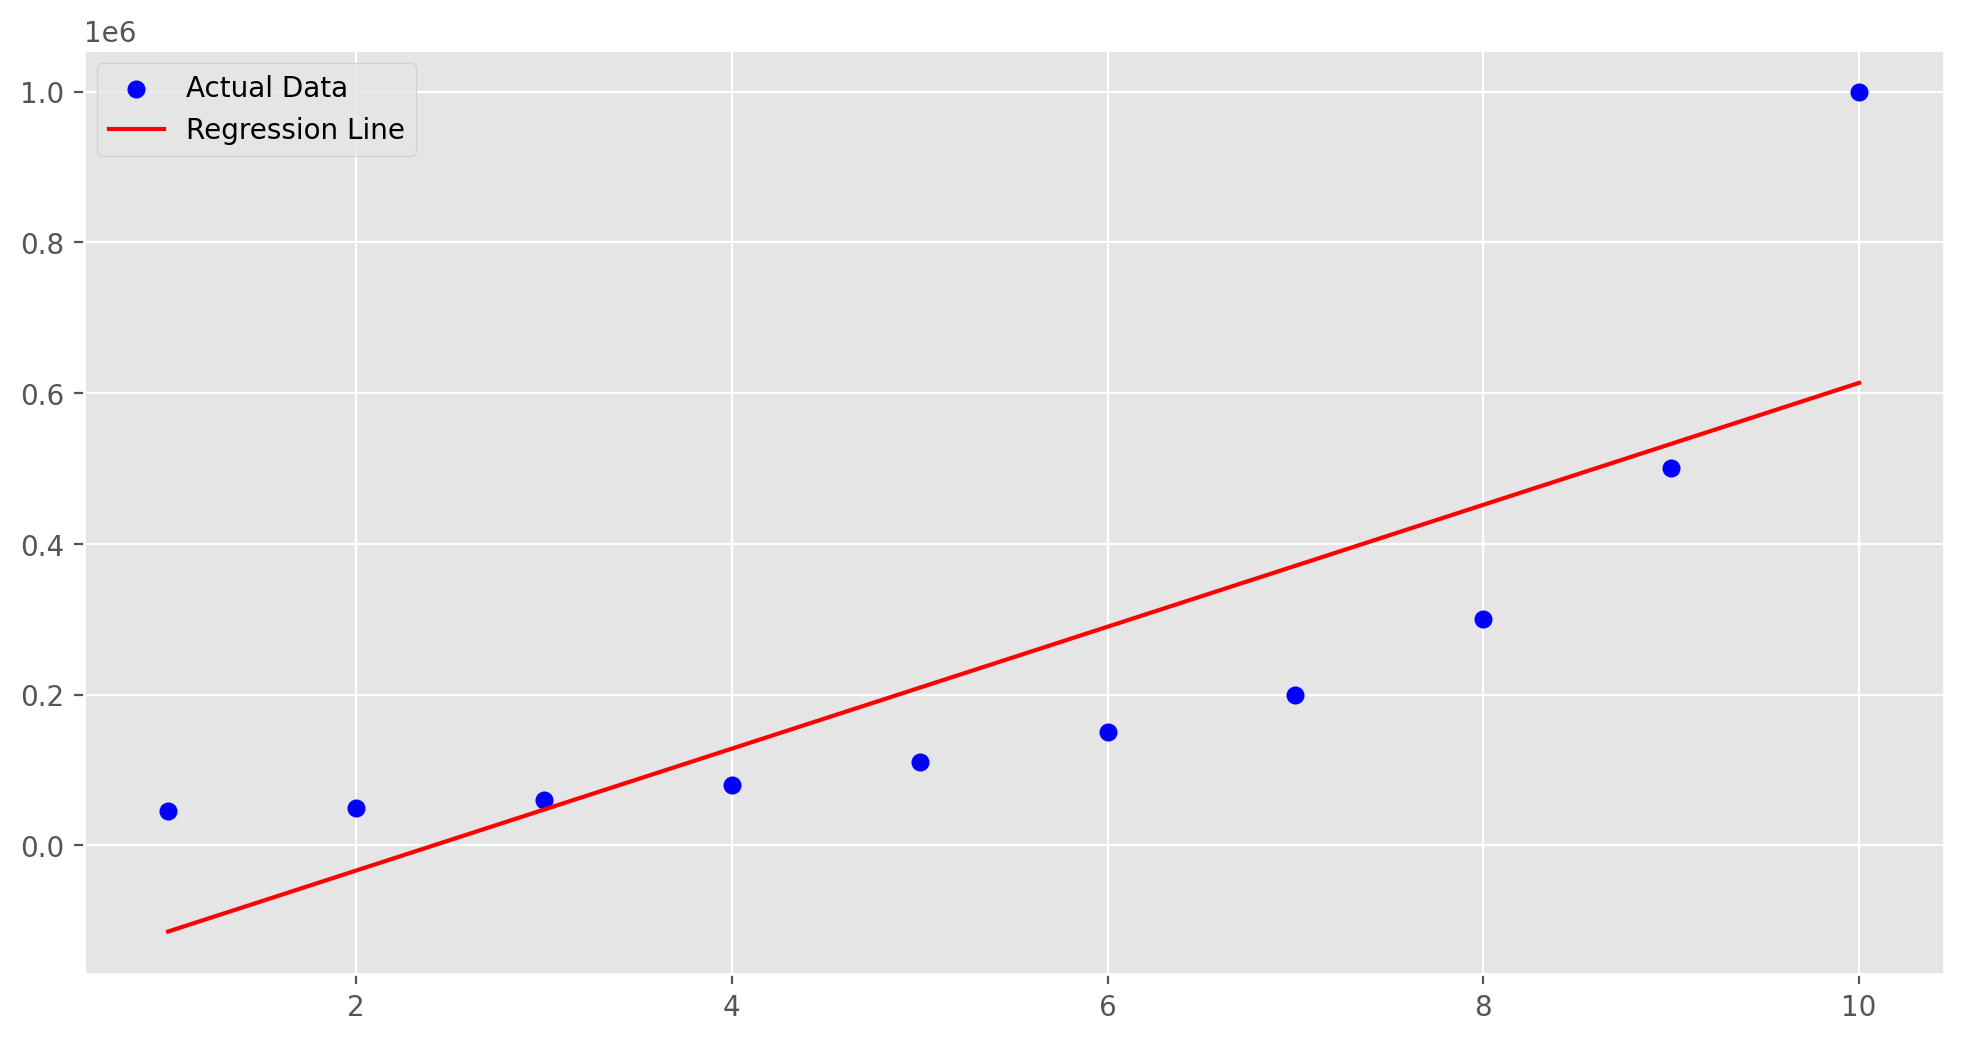

In [47]:
pred1 = lin_reg.predict(x)
plt.figure(figsize = (12,6), dpi = 200)
plt.scatter(x,y, c = 'b', label = 'Actual Data')#legned c = color
plt.plot(x, pred1, c = 'r', label = 'Regression Line')
plt.legend()

In [49]:
#using polynomial REgression as linear function is not capable of caputring non linear patters 
#to capture nonlinear relationship we need to add higer values

In [51]:
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree = 2)
x_poly2 = poly.fit_transform(x)
x_poly2

array([[  1.,   1.,   1.],
       [  1.,   2.,   4.],
       [  1.,   3.,   9.],
       [  1.,   4.,  16.],
       [  1.,   5.,  25.],
       [  1.,   6.,  36.],
       [  1.,   7.,  49.],
       [  1.,   8.,  64.],
       [  1.,   9.,  81.],
       [  1.,  10., 100.]])

In [55]:
poly_reg2 = LinearRegression()
poly_reg2.fit(x_poly2, y)
poly_reg2.score(x_poly2, y)

0.9162082221443942

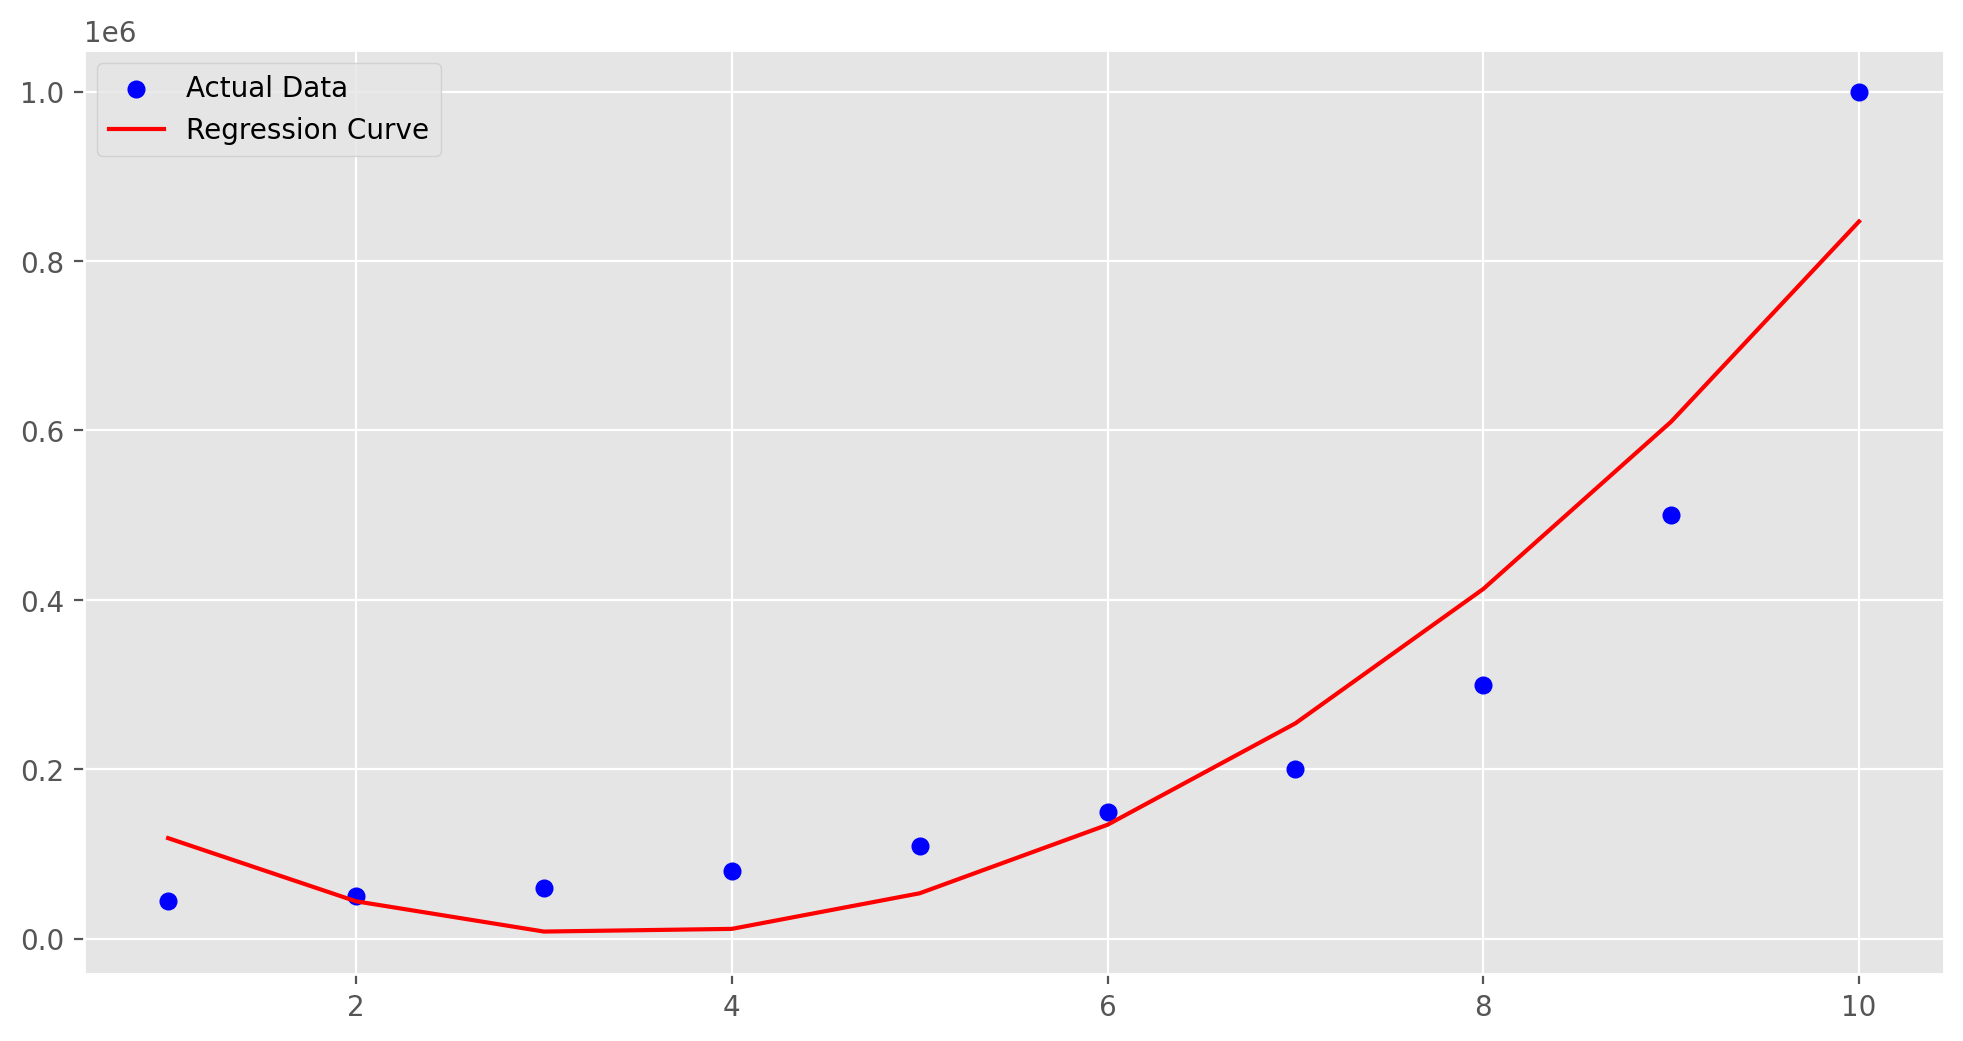

In [61]:
pred2 = poly_reg2.predict(x_poly2)
plt.figure(figsize = (12,6), dpi = 200)
plt.scatter(x,y, c= 'b', label ="Actual Data")
plt.plot(x, pred2, c = 'r', label ="Regression Curve")
plt.legend()

In [63]:
poly_reg2.coef_

array([[      0.        , -132871.21212121,   19431.81818182]])

In [65]:
#with degree 3
poly = PolynomialFeatures(degree =3 )
x_poly3 = poly.fit_transform(x)
x_poly3

array([[   1.,    1.,    1.,    1.],
       [   1.,    2.,    4.,    8.],
       [   1.,    3.,    9.,   27.],
       [   1.,    4.,   16.,   64.],
       [   1.,    5.,   25.,  125.],
       [   1.,    6.,   36.,  216.],
       [   1.,    7.,   49.,  343.],
       [   1.,    8.,   64.,  512.],
       [   1.,    9.,   81.,  729.],
       [   1.,   10.,  100., 1000.]])

In [69]:
poly_reg3 = LinearRegression()
poly_reg3.fit(x_poly3, y)
poly_reg3.score(x_poly3, y)


0.9812097727913366

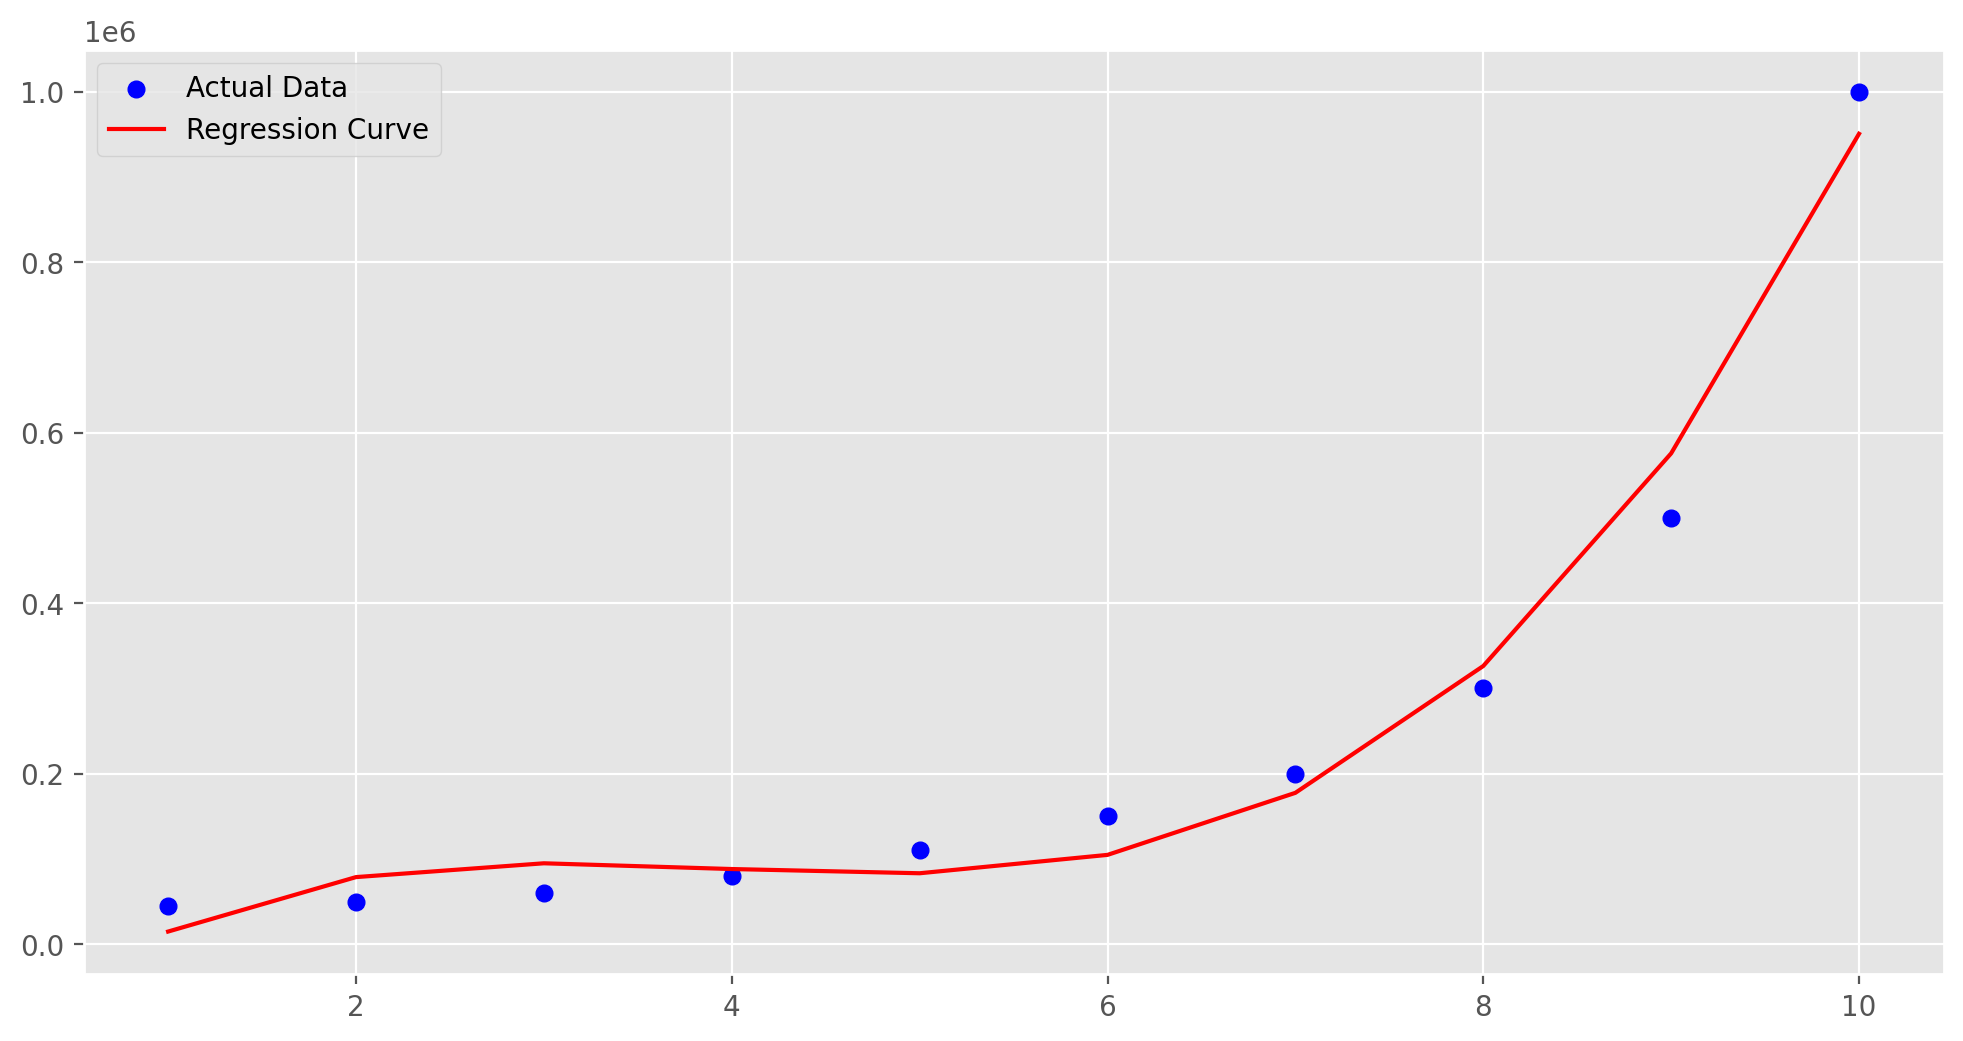

In [73]:
pred3 = poly_reg3.predict(x_poly3)
plt.figure(figsize = (12,6), dpi =200)
plt.scatter(x, y, c ='b', label ='Actual Data')
plt.plot(x, pred3, c ='r', label ='Regression Curve')
plt.legend()
         

In [77]:
poly = PolynomialFeatures(degree = 6)
x_poly6 = poly.fit_transform(x)
poly_reg6 = LinearRegression()
poly_reg6.fit(x_poly6, y)
poly_reg6.score(x_poly6, y)

0.9999494749253776

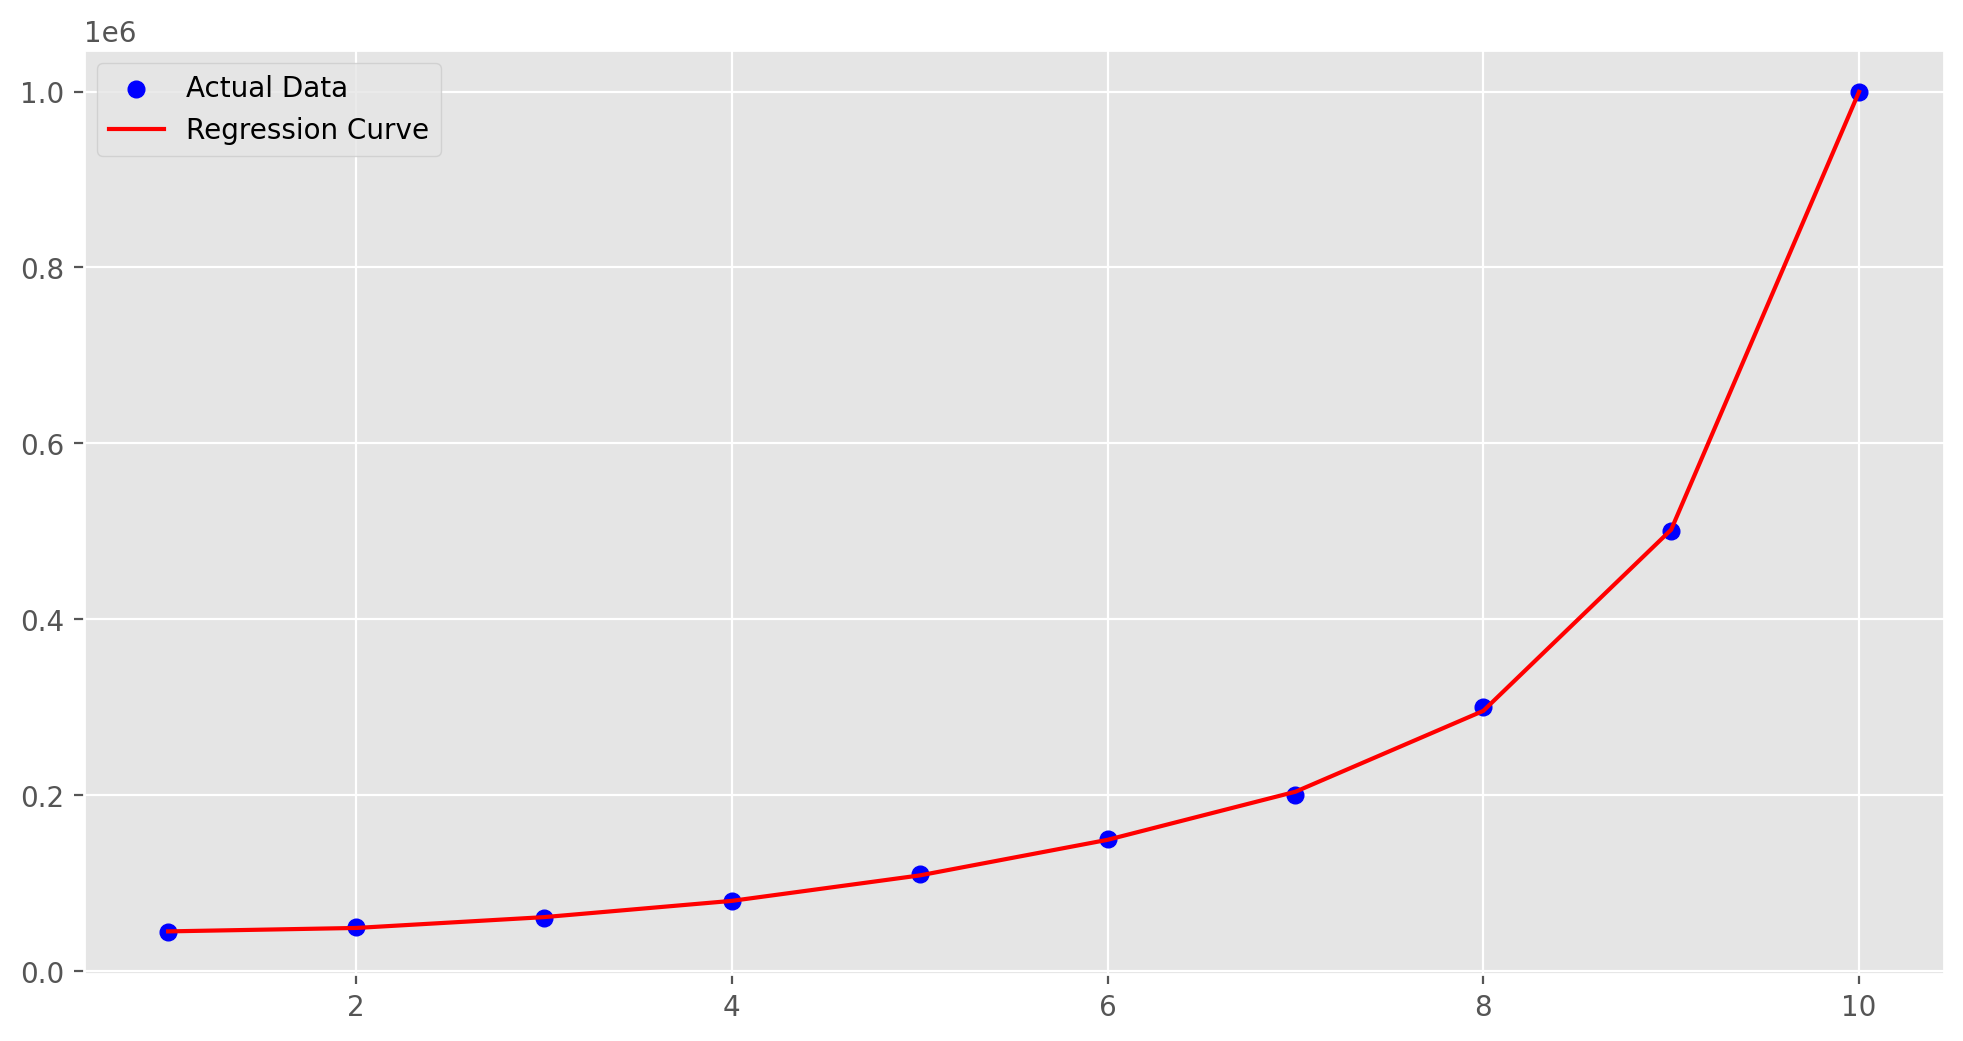

In [79]:
pred6 = poly_reg6.predict(x_poly)
plt.figure(figsize =(12,6), dpi = 200)
plt.scatter(x, y, c='b', label ='Actual Data')
plt.plot(x, pred6, c='r', label ='Regression Curve')
plt.legend()

In [81]:
#comparing result

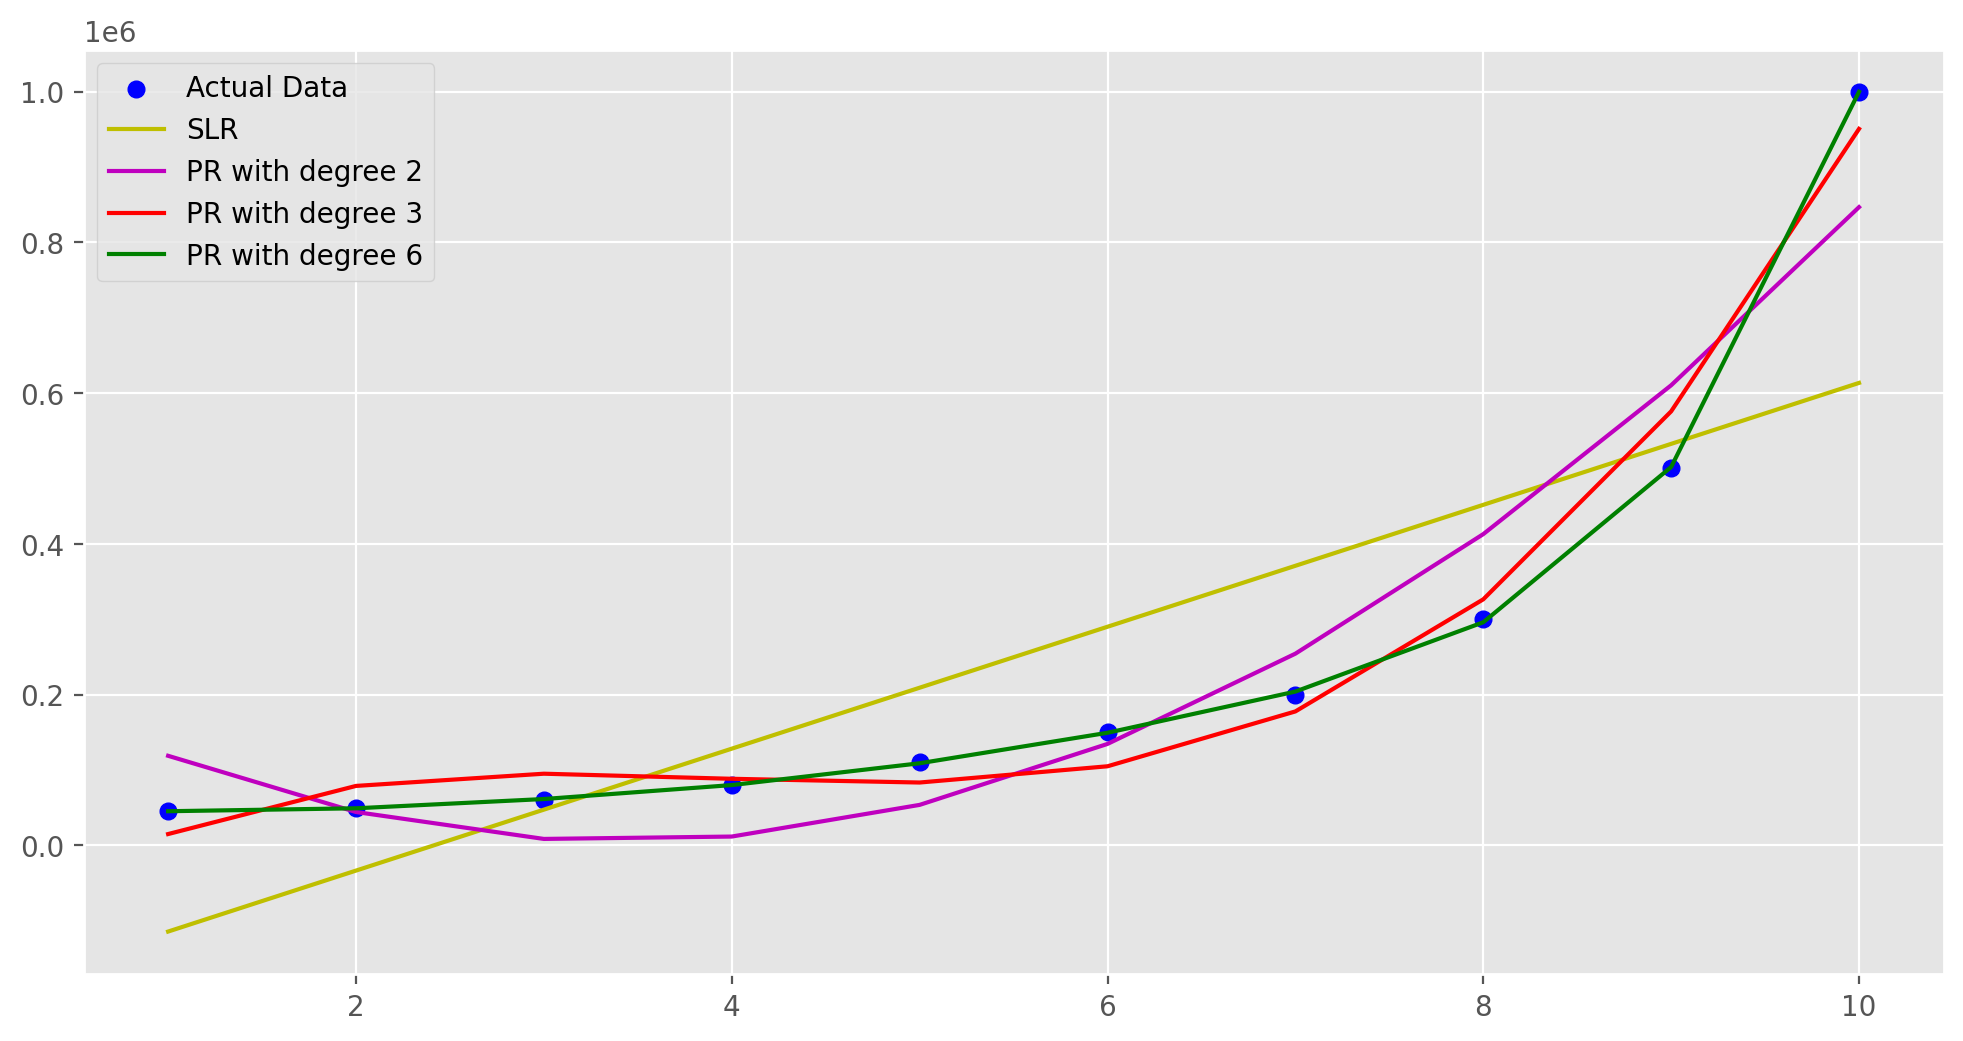

In [89]:
plt.figure(figsize= (12,6), dpi = 200)
plt.scatter(x, y, c='b', label ='Actual Data')
plt.plot(x, pred1, c='y', label='SLR')
plt.plot(x, pred2, c='m', label='PR with degree 2')
plt.plot(x, pred3 ,c='r', label='PR with degree 3')
plt.plot(x, pred6 ,c='g', label= 'PR with degree 6')

plt.legend()

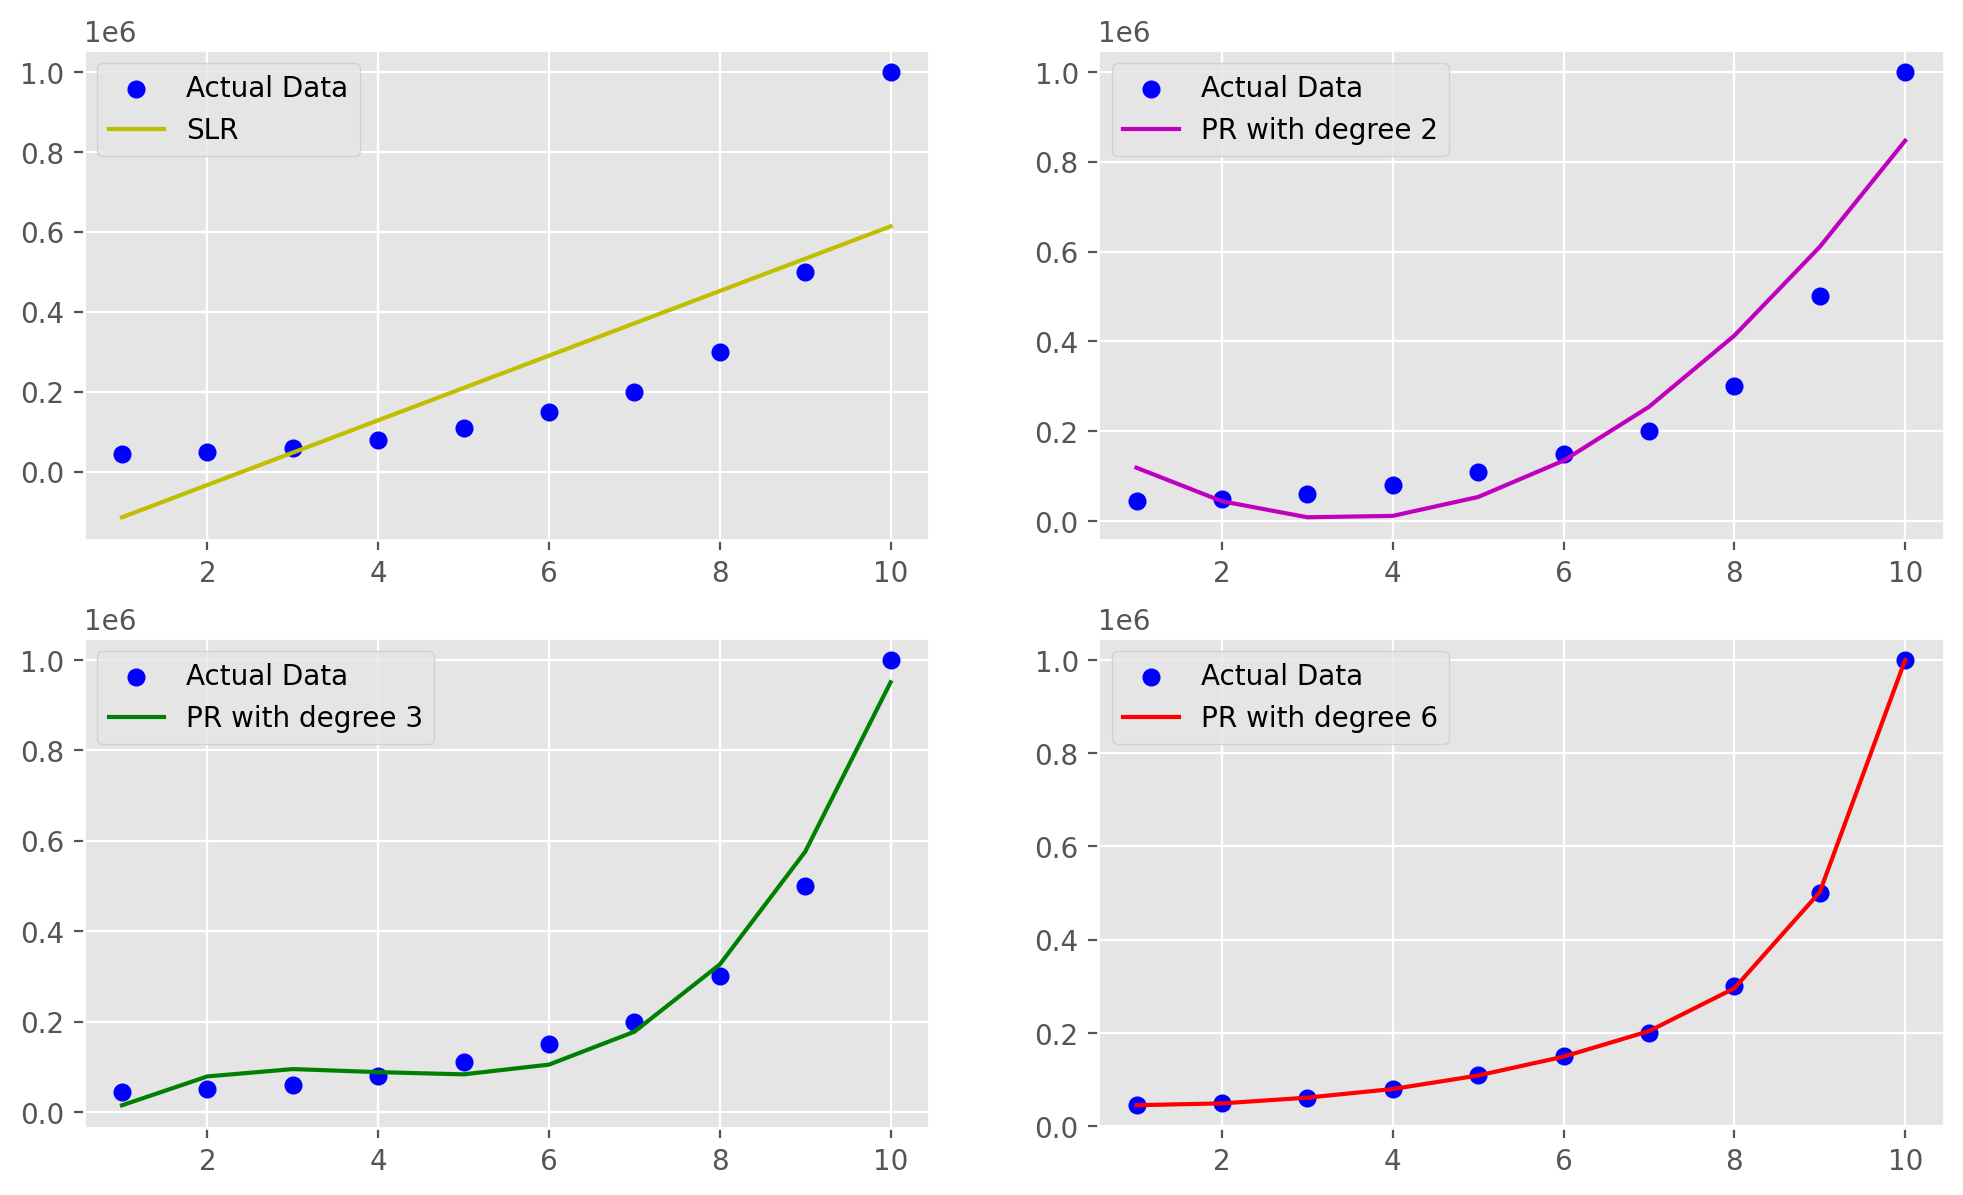

In [102]:
plt.figure(figsize = (12,7), dpi = 200)
plt.subplot(2,2,1)
plt.scatter(x,y, c = 'b', label = 'Actual Data')
plt.plot(x, pred1, c = 'y', label = 'SLR')
plt.legend()

plt.subplot(2,2,2)
plt.scatter(x,y, c = 'b', label = 'Actual Data')
plt.plot(x, pred2, c = 'm', label = 'PR with degree 2')
plt.legend()

plt.subplot(2,2,3)
plt.scatter(x,y, c = 'b', label = 'Actual Data')
plt.plot(x, pred3, c = 'g', label = 'PR with degree 3')
plt.legend()

plt.subplot(2,2,4)
plt.scatter(x,y, c = 'b', label = 'Actual Data')
plt.plot(x, pred6, c = 'r', label = 'PR with degree 6')
plt.legend()
